In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyexpat import features
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression  # o Ridge, Lasso
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from matplotlib import pyplot as plt

maestro_zonas = pd.read_csv('D:\\Data\\frusan\\cleanest\\maestro_zonas.csv')
temperatura_path_pattern = 'D:\\Data\\frusan\\cleanest\\temp_zone={}.csv'
temperaturas = {}
for _, (zona_id, zona_name) in maestro_zonas.iterrows():
    temperaturas[zona_name] = pd.read_csv(temperatura_path_pattern.format(zona_id - - 1))
    # Parse date in column fecha_datetime with format day month year
    temperaturas[zona_name]['fecha_datetime'] = pd.to_datetime(temperaturas[zona_name]['fecha_datetime'],
                                                               format='mixed', dayfirst=True)
for zona_name, temp_df in temperaturas.items():
    print(f'Zona: {zona_name}, Temp DataFrame shape: {temp_df.shape}')
    print(f"Has nulls: {temp_df.isnull().any().any()} null percentage : {temp_df.isnull().mean().mean() * 100:.2f}%")
    print(f"Filling null values with forward fill method.")
    temp_df.ffill(inplace=True)
    print(f"After filling, has nulls: {temp_df.isnull().any().any()}")

Zona: melipilla, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 0.14%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: viluco, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 0.14%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: pichidegua, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 0.24%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: teno prado, Temp DataFrame shape: (7728, 2)
Has nulls: True null percentage : 1.65%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: santa ana, Temp DataFrame shape: (7768, 2)
Has nulls: True null percentage : 0.13%
Filling null values with forward fill method.
After filling, has nulls: False
Zona: teno don sergio, Temp DataFrame shape: (7768, 2)
Has nulls: True null percentage : 0.13%
Filling null values with forward fill method.
After filling, has nulls:

In [4]:
def rename_zone(str_i):
    mapping = {
        'sta magdalena (los niches 2)': 'santa magdalena',
        'teno oriente': 'teno prado',
        'teno monta�a': 'teno don sergio',
        'teno poniente': 'santa ana',
        'wapri (los niches 1)': 'wapri',
    }
    return mapping.get(str_i, str_i)
df_p = pd.read_csv('D:\\Data\\frusan\\clean\\dataset_caida_hojas_brotacion_en_camara_ent_2024.csv', sep=";")
df_p['zona'] = df_p['zona'].apply(rename_zone)
df_p['zona_variedad_tratamiento'] = df_p['zona'] + '_' + df_p['variedad'] + '_' + df_p['tratamiento']
df_p

,key,caida_de_hojas_date,brotacion_en_camara_50_date,dias_acumulando_frio,zona,variedad,ue_str,tratamiento,ue_int,zona_variedad_tratamiento
0,Melipilla-Santina-001-Zn+Eth,08-05-2024,09-07-2024,62.0,melipilla,santina,1,zn+eth,1,melipilla_santina_zn+eth
1,Melipilla-Santina-002-Fsh,08-05-2024,12-07-2024,65.0,melipilla,santina,2,fsh,2,melipilla_santina_fsh
2,Melipilla-Santina-003-Control,08-05-2024,12-07-2024,65.0,melipilla,santina,3,control,3,melipilla_santina_control
3,Melipilla-Santina-004-Zn+U+Eth,08-05-2024,12-07-2024,65.0,melipilla,santina,4,zn+u+eth,4,melipilla_santina_zn+u+eth
4,Melipilla-Santina-005-Ethephon,15-05-2024,12-07-2024,58.0,melipilla,santina,5,ethephon,5,melipilla_santina_ethephon
...,...,...,...,...,...,...,...,...,...,...
415,Wapri (Los Niches 1)-Regina-026-Ethephon,07-05-2024,21-07-2024,74.0,wapri,regina,26,ethephon,26,wapri_regina_ethephon
416,Wapri (Los Niches 1)-Regina-027-Control,12-05-2024,20-07-2024,68.0,wapri,regina,27,control,27,wapri_regina_control
417,Wapri (Los Niches 1)-Regina-028-Zn+Eth,06-05-2024,20-07-2024,74.0,wapri,regina,28,zn+eth,28,wapri_regina_zn+eth
418,Wapri (Los Niches 1)-Regina-029-Fsh,08-05-2024,20-07-2024,72.0,wapri,regina,29,fsh,29,wapri_regina_fsh


In [5]:
df_p['caida_de_hojas_date'] = pd.to_datetime(df_p['caida_de_hojas_date'], errors="coerce", dayfirst=True, format="mixed")
df_p['brotacion_en_camara_50_date'] = pd.to_datetime(df_p['brotacion_en_camara_50_date'], errors="coerce", dayfirst=True, format="mixed")
df_p = df_p.dropna()

In [6]:
def count_chill_hours(temp_series, contabilization_function):
    # Apply the contabilization function to the temperature series
    chill_hours = temp_series.apply(contabilization_function)
    return chill_hours.sum()

In [7]:
def utah_chill_function(temp):
    if temp < 1.4:
        return 0
    elif 1.4 <= temp < 2.4:
        return 0.5
    elif 2.4 <= temp < 9.1:
        return 1
    elif 9.1 <= temp < 12.4:
        return 0.5
    elif 12.4 <= temp < 15.9:
        return 0
    elif 15.9 <= temp < 18:
        return -0.5
    else:  # temp >= 18
        return -1

In [8]:
def positive_utah_chill_function(temp):
    chill = utah_chill_function(temp)
    return max(chill, 0)

In [9]:
# For each row in df_p, calculate the chill hours between the planting date and the caida_de_hojas_date on the corresponding temperature dataframe
chill_hours_list = []
for _, row in df_p.iterrows():
    zona_name = row['zona']
    temp_df = temperaturas[zona_name]
    start = row['caida_de_hojas_date']
    end = row['brotacion_en_camara_50_date']
    mask = (temp_df['fecha_datetime'] >= start) & (temp_df['fecha_datetime'] <= end)
    temp_series = temp_df.loc[mask, 'temperatura']
    chill_hours = count_chill_hours(temp_series, utah_chill_function)
    chill_hours_list.append(chill_hours)
df_p['chill_hours_utah'] = chill_hours_list

C:\Users\gusta\AppData\Local\Temp\ipykernel_32088\1424543090.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p['chill_hours_utah'] = chill_hours_list


In [23]:
# Eligamos dos fechas fijas y calculemos las chill hours entre esas fechas para cada zona y luego entrenemos un modelo simple de regresion lineal para predecir la cantidad de dias en latencia necesarias para cada unidad experimental tomando como input solo las variables categoricas y las chill hour disponibles entre esas dos fechas fijas.


TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.6, 0.2, 0.2
RANDOM_STATE = 117

start_season, end_season = pd.to_datetime('2024-05-01'), pd.to_datetime('2024-08-01')
season_25 = start_season + (end_season - start_season) * 0.25
season_50 = start_season + (end_season - start_season) * 0.50
season_75 = start_season + (end_season - start_season) * 0.75
print(start_season, season_25, season_50, season_75, end_season)

# We calculate chill hours between fixed dates at 25%, 50% and 75% of the season
chill_hours_25_list = []
chill_hours_50_list = []
chill_hours_75_list = []
chill_hours_fixed_list = []

for _, row in df_p.iterrows():
    zona_name = row['zona']
    temp_df = temperaturas[zona_name]

    mask_25 = (temp_df['fecha_datetime'] >= start_season) & (temp_df['fecha_datetime'] <= season_25)
    temp_series_25 = temp_df.loc[mask_25, 'temperatura']
    chill_hours_25 = count_chill_hours(temp_series_25, utah_chill_function)
    chill_hours_25_list.append(chill_hours_25)

    mask_50 = (temp_df['fecha_datetime'] >= start_season) & (temp_df['fecha_datetime'] <= season_50)
    temp_series_50 = temp_df.loc[mask_50, 'temperatura']
    chill_hours_50 = count_chill_hours(temp_series_50, utah_chill_function)
    chill_hours_50_list.append(chill_hours_50)

    mask_75 = (temp_df['fecha_datetime'] >= start_season) & (temp_df['fecha_datetime'] <= season_75)
    temp_series_75 = temp_df.loc[mask_75, 'temperatura']
    chill_hours_75 = count_chill_hours(temp_series_75, utah_chill_function)
    chill_hours_75_list.append(chill_hours_75)

    mask_fixed = (temp_df['fecha_datetime'] >= start_season) & (temp_df['fecha_datetime'] <= end_season)
    temp_series_fixed = temp_df.loc[mask_fixed, 'temperatura']
    chill_hours_fixed = count_chill_hours(temp_series_fixed, utah_chill_function)
    chill_hours_fixed_list.append(chill_hours_fixed)

df_p['chill_hours_25'] = chill_hours_25_list
df_p['chill_hours_50'] = chill_hours_50_list
df_p['chill_hours_75'] = chill_hours_75_list
df_p['chill_hours_fixed'] = chill_hours_fixed_list

2024-05-01 00:00:00 2024-05-24 00:00:00 2024-06-16 00:00:00 2024-07-09 00:00:00 2024-08-01 00:00:00


C:\Users\gusta\AppData\Local\Temp\ipykernel_32088\1060169385.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p['chill_hours_25'] = chill_hours_25_list
C:\Users\gusta\AppData\Local\Temp\ipykernel_32088\1060169385.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p['chill_hours_50'] = chill_hours_50_list
C:\Users\gusta\AppData\Local\Temp\ipykernel_32088\1060169385.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

In [27]:
# Hagamos la seleccion de features y el split de los datos
features_cols = [
    'zona', 'variedad', 'tratamiento',
    'chill_hours_25', 'chill_hours_50', 'chill_hours_75', 'chill_hours_fixed'
]

X = df_p[features_cols]
y = (df_p['brotacion_en_camara_50_date'] - df_p['caida_de_hojas_date']).dt.days

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
relative_val_size = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=relative_val_size, random_state=RANDOM_STATE
)
print(f'Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 216, Val size: 72, Test size: 72


In [28]:
# Construyamos el pipeline de sklearn
categorical_features = ['zona', 'variedad', 'tratamiento']
numerical_features = [
    'chill_hours_25', 'chill_hours_50', 'chill_hours_75', 'chill_hours_fixed'
]

categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = 'passthrough'
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ]
)


In [31]:
# Baseline: siempre predecir la media de y_train
baseline_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)

MAE_baseline = mean_absolute_error(y_val, baseline_pred)
print("MAE baseline (predice media):", MAE_baseline)


MAE baseline (predice media): 6.737268518518519


In [32]:
# Modelo de regresión lineal
regressor = LinearRegression()

# Pipeline completo: preprocesar -> modelo
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", regressor),
])

# Entrenar
model.fit(X_train, y_train)

# Evaluar rápido en validación
y_val_pred = model.predict(X_val)
# Check nan in predictions
print("MAE val:", mean_absolute_error(y_val, y_val_pred))
print("R^2 val:", r2_score(y_val, y_val_pred))

MAE val: 4.0360231781265306
R^2 val: 0.7009449116265896


In [34]:
# Modelo de regresión lineal
regressor = Ridge(1.0)
# Si quieres regularización:
# from sklearn.linear_model import Ridge
# regressor = Ridge(alpha=1.0)

# Pipeline completo: preprocesar -> modelo
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", regressor),
])

# Entrenar
model.fit(X_train, y_train)

# Evaluar rápido en validación
from sklearn.metrics import mean_absolute_error, r2_score
y_val_pred = model.predict(X_val)
# Check nan in predictions
print("MAE val:", mean_absolute_error(y_val, y_val_pred))
print("R^2 val:", r2_score(y_val, y_val_pred))

MAE val: 3.9912976373115074
R^2 val: 0.7047302249181303


In [35]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),  # el mismo que usaste en la regresión lineal
    ("regressor", RandomForestRegressor(
        n_estimators=500,
        max_depth=5,          # controla complejidad, puedes jugar con esto
        min_samples_leaf=5,   # evita sobreajuste con pocos datos
        random_state=42,
        n_jobs=-1
    )),
])

rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)

MAE_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)

print("RF MAE val:", MAE_val_rf)
print("RF R^2 val:", r2_val_rf)


RF MAE val: 3.5774515755313447
RF R^2 val: 0.7481970823318108


In [36]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),  # el mismo que usaste antes
    ("regressor", XGBRegressor(
        n_estimators=300,          # pocos árboles por tamaño de muestra
        learning_rate=0.05,        # pasitos chicos
        max_depth=3,               # árboles bajos = menos overfit
        min_child_weight=5,        # evita splits con muy pocos datos
        subsample=0.8,             # bagging de filas
        colsample_bytree=0.8,      # bagging de columnas
        reg_lambda=1.0,            # L2
        reg_alpha=0.0,             # L1 (puedes luego probar >0)
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",        # rápido en CPU
        n_jobs=-1,
    )),
])

xgb_model.fit(X_train, y_train)

y_val_pred_xgb = xgb_model.predict(X_val)

MAE_val_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
r2_val_xgb = r2_score(y_val, y_val_pred_xgb)

print("XGB MAE val:", MAE_val_xgb)
print("XGB R^2 val:", r2_val_xgb)


XGB MAE val: 3.3753929138183594
XGB R^2 val: 0.7683923244476318


In [38]:
# Imprimamos un resumen general
print("Resumen de resultados en validación:")
print(f"Baseline MAE: {MAE_baseline:.4f} y (R^2: 0.0000)")
print(f"Linear Regression MAE: {mean_absolute_error(y_val, y_val_pred):.4f} y (R^2: {r2_score(y_val, y_val_pred):.4f})")
print(f"Ridge MAE: {mean_absolute_error(y_val, model.predict(X_val)):.4f} y (R^2: {r2_score(y_val, model.predict(X_val)):.4f})")
print(f"Random Forest MAE: {MAE_val_rf:.4f} y (R^2: {r2_val_rf:.4f})")
print(f"XGBoost MAE: {MAE_val_xgb:.4f} y (R^2: {r2_val_xgb:.4f})")

Resumen de resultados en validación:
Baseline MAE: 6.7373 y (R^2: 0.0000)
Linear Regression MAE: 3.9913 y (R^2: 0.7047)
Ridge MAE: 3.9913 y (R^2: 0.7047)
Random Forest MAE: 3.5775 y (R^2: 0.7482)
XGBoost MAE: 3.3754 y (R^2: 0.7684)


In [39]:
# Elijamos el mejor modelo automáticamente segun R2 en validación
model_scores = {
    "Linear Regression": r2_score(y_val, y_val_pred),
    "Ridge": r2_score(y_val, model.predict(X_val)),
    "Random Forest": r2_val_rf,
    "XGBoost": r2_val_xgb,
}
best_model_name = max(model_scores, key=model_scores.get)
print(f"Mejor modelo en validación: {best_model_name} con R^2 = {model_scores[best_model_name]:.4f}")

Mejor modelo en validación: XGBoost con R^2 = 0.7684


In [40]:
if best_model_name == "Linear Regression":
    best_model = model
elif best_model_name == "Ridge":
    best_model = model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = xgb_model


In [42]:
# Evaluemos el mejor modelo en test
y_test_pred = best_model.predict(X_test)
MAE_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"Desempeño en test del mejor modelo ({best_model_name}):")
print(f"MAE test: {MAE_test:.4f}")
print(f"R^2 test: {r2_test:.4f}")


Desempeño en test del mejor modelo (XGBoost):
MAE test: 3.0443
R^2 test: 0.8103


In [44]:
# Write to a file a summary of the results
with open("model_quicktest_results_new_Run.txt", "w", encoding='UTF-8') as f:
    f.write("Resumen de resultados en validación:\n")
    f.write(f"Baseline MAE: {MAE_baseline:.4f} y (R^2: 0.0000)\n")
    f.write(f"Linear Regression MAE: {mean_absolute_error(y_val, y_val_pred):.4f} y (R^2: {r2_score(y_val, y_val_pred):.4f})\n")
    f.write(f"Ridge MAE: {mean_absolute_error(y_val, model.predict(X_val)):.4f} y (R^2: {r2_score(y_val, model.predict(X_val)):.4f})\n")
    f.write(f"Random Forest MAE: {MAE_val_rf:.4f} y (R^2: {r2_val_rf:.4f})\n")
    f.write(f"XGBoost MAE: {MAE_val_xgb:.4f} y (R^2: {r2_val_xgb:.4f})\n")
    f.write(f"Mejor modelo en validación: {best_model_name} con R^2 = {model_scores[best_model_name]:.4f}\n")
    f.write(f"\nDesempeño en test del Baseline (predice media):\n")
    f.write(f"MAE test: {mean_absolute_error(y_test, np.full_like(y_test, fill_value=y_train.mean(), dtype=float)):.4f}\n")
    f.write(f"R^2 test: {0.0:.4f}\n")
    f.write(f"Desempeño en test del mejor modelo ({best_model_name}):\n")
    f.write(f"MAE test: {MAE_test:.4f}\n")
    f.write(f"R^2 test: {r2_test:.4f}\n")

    # Añadamos las metricas obtenidas al evaluar por variedad
    f.write("\nDesempeño por variedad en test:\n")
    variedades = X_test["variedad"].unique()
    for variedad in variedades:
        mask = X_test["variedad"] == variedad
        y_true_var = y_test[mask]
        y_pred_var = y_test_pred[mask]
        mae_var = mean_absolute_error(y_true_var, y_pred_var)
        # Veamos el mae si solo usamos el promedio
        mae_var_baseline = mean_absolute_error(y_true_var, np.full_like(y_true_var, fill_value=y_train.mean(), dtype=float))
        f.write(f"Variedad {variedad}: MAE = {mae_var:.4f} | BaselineMAE = {mae_var_baseline:.4f}\n")


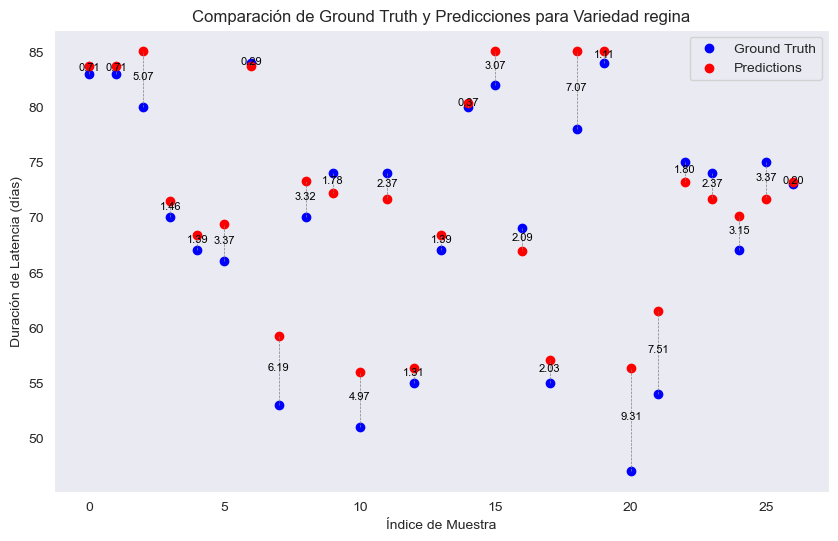

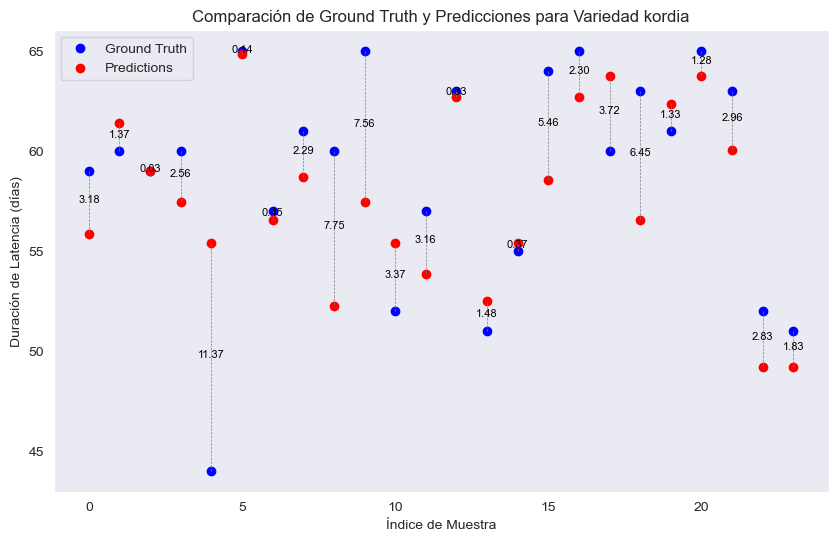

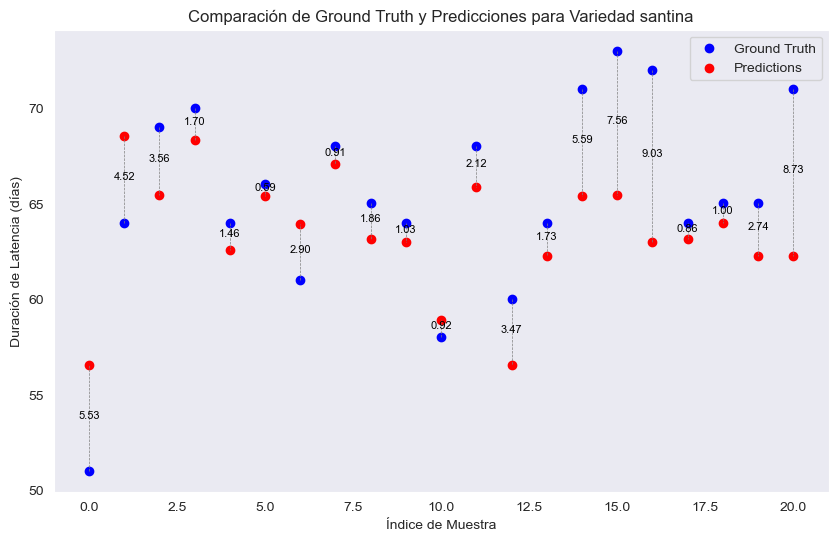

In [46]:
# Hagamos un grafico agrupado por variedad mostrando la comparacion del ground truth con el label de 3 puntos por variedad de manera aleatoria
# Dibuja una linea entre los puntos de ground truth y predicciones para cada punto y anota la diferencia en cada punto
variedades = X_test["variedad"].unique()
for variedad in variedades:
    mask = X_test["variedad"] == variedad
    y_true_var = y_test[mask]
    y_pred_var = y_test_pred[mask]

    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(y_true_var)), y_true_var, color='blue', label='Ground Truth')
    plt.scatter(range(len(y_pred_var)), y_pred_var, color='red', label='Predictions')

    for i in range(len(y_true_var)):
        plt.plot([i, i], [y_true_var.iloc[i], y_pred_var[i]], color='gray', linestyle='--', linewidth=0.5)
        plt.text(i, (y_true_var.iloc[i] + y_pred_var[i]) / 2, f"{abs(y_true_var.iloc[i] - y_pred_var[i]):.2f}",
                 fontsize=8, color='black', ha='center')

    plt.title(f'Comparación de Ground Truth y Predicciones para Variedad {variedad}')
    plt.xlabel('Índice de Muestra')
    plt.ylabel('Duración de Latencia (días)')
    plt.legend()
    plt.grid()
    plt.show()